# V055 — Validate pressure-waveform morphology without source-time circularity

**Status:** validation/support notebook; **not** part of the production paper pipeline.

This notebook preserves the waveform evidence needed for manuscript statements about the shape of the strongest BCHH pressure transients while explicitly avoiding the old circular timing problem.

### Principle

All four named-event waveform windows are centered on the **directly measured DD2/DD3 receiver arrival picks** in `bchh_named_event_pressure_arrival_picks.csv`. No 351 m/s source-time reduction and no video-derived source time is used to place the waveform windows.

For the broader event ensemble, the notebook reads the normalized high-quality waveform products produced by the production amplitude/coupling notebook when available. Those products are used only to describe waveform morphology; they do not determine source timing.

The intended manuscript-level conclusion is descriptive: the strongest pressure pulses show rapid compression followed by a smaller, longer rarefaction and are therefore **Friedlander-like**. This notebook does not infer Mach number from waveform shape alone and does not require a classical symmetric N-wave.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime

here = Path.cwd().resolve()
ROOT = next(
    (p for p in [here, *here.parents] if (p / "modules" / "project_config.py").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("Run from the Falcon 9 repository or a subdirectory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from modules import project_config as config

OUT = config.notebook_output_dir(55, "validate_waveform_morphology")
OUT.mkdir(parents=True, exist_ok=True)

BASELINE_STREAM_FILE = (
    config.NB010_DIR / "bchh_corrected_moving_median_baseline_removed.pkl"
)
ENSEMBLE_WAVEFORMS_FILE = (
    config.NB070_DIR / "high_quality_normalized_waveforms.csv"
)
ENSEMBLE_METADATA_FILE = (
    config.NB070_DIR / "high_quality_normalized_waveform_metadata.csv"
)

ARRIVALS = config.BCHH_NAMED_EVENT_ARRIVAL_PICKS.copy()
EVENT_ORDER = [
    "upper_stage",
    "lower_stage",
    "payload_impact",
    "payload_explosion",
]

display(
    ARRIVALS[["event", "trace_id", "channel", "pick_time_utc"]]
    .sort_values(["event", "channel"])
)

,event,trace_id,channel,pick_time_utc
2,lower_stage,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:19.427235Z
3,lower_stage,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:19.438250Z
6,payload_explosion,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:28.987823Z
7,payload_explosion,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:28.995974Z
4,payload_impact,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:28.407995Z
5,payload_impact,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:28.415926Z
0,upper_stage,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:15.927934Z
1,upper_stage,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:15.935523Z


## 1. Plot named-event pressure waveforms around measured receiver arrivals

The plotting origin for each trace is its own reviewed arrival pick. This is deliberately independent of both the SpaceX video timing and the legacy model-derived source-time coordinate.

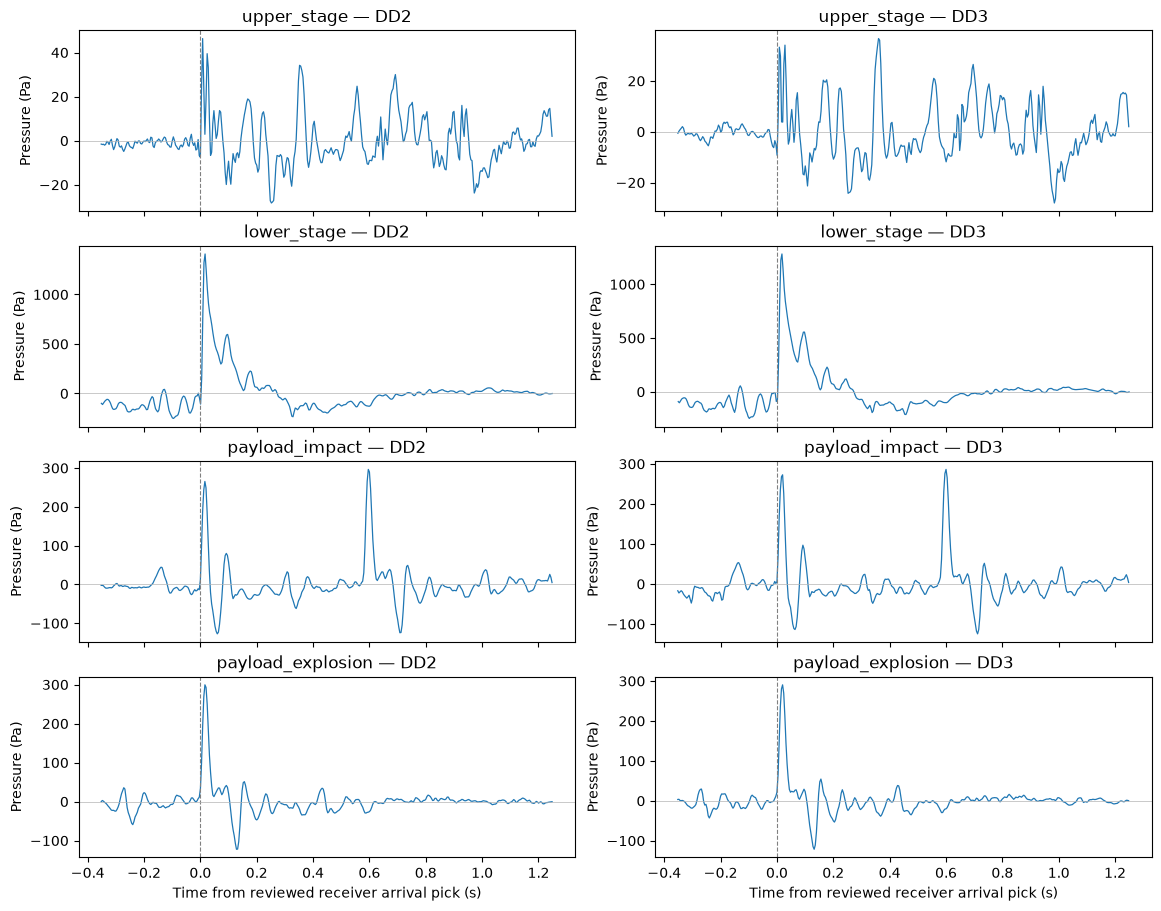

,event,channel,positive_peak_pa,positive_peak_time_after_pick_s,following_negative_peak_pa,negative_peak_time_after_pick_s,negative_to_positive_amplitude_ratio
0,upper_stage,DD2,46.355688,0.008066,-28.274694,0.252066,0.609951
1,upper_stage,DD3,36.670214,0.360477,-28.055593,0.984477,0.765079
2,lower_stage,DD2,1409.432141,0.016765,-235.176657,0.328765,0.166859
3,lower_stage,DD3,1282.034581,0.017750,-211.925236,0.457750,0.165304
4,payload_impact,DD2,296.539716,0.596005,-124.437590,0.708005,0.419632
5,payload_impact,DD3,286.184936,0.600074,-124.454430,0.712074,0.434874
6,payload_explosion,DD2,299.352583,0.016177,-122.240319,0.128177,0.408349
7,payload_explosion,DD3,290.456323,0.020026,-121.415996,0.132026,0.418018


In [2]:
if not BASELINE_STREAM_FILE.is_file():
    raise FileNotFoundError(
        f"Missing {BASELINE_STREAM_FILE}. Run production Notebook 010 first."
    )

import pickle
with BASELINE_STREAM_FILE.open("rb") as handle:
    st = pickle.load(handle)

PRESSURE_CHANNELS = ("DD1", "DD2", "DD3")
PRE_S = 0.35
POST_S = 1.25
DISPLAY_BANDPASS_HZ = (0.5, 80.0)


def one_trace(channel):
    selected = st.select(channel=channel)
    if len(selected) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(selected)}")
    return selected[0]


def arrival(event, channel):
    row = ARRIVALS.loc[
        ARRIVALS["event"].eq(event) & ARRIVALS["channel"].eq(channel)
    ]
    if len(row) != 1:
        raise ValueError(f"Expected one arrival for {event}/{channel}")
    return row.iloc[0]["pick_time"]


fig, axes = plt.subplots(
    len(EVENT_ORDER), 2,
    figsize=(11.5, 9.0),
    sharex=True,
    constrained_layout=True,
)

morphology_rows = []
for row_i, event in enumerate(EVENT_ORDER):
    for col_i, channel in enumerate(("DD2", "DD3")):
        ax = axes[row_i, col_i]
        t0 = arrival(event, channel)
        tr = one_trace(channel).copy().trim(t0 - PRE_S, t0 + POST_S)
        tr.detrend("demean")
        tr.filter(
            "bandpass",
            freqmin=DISPLAY_BANDPASS_HZ[0],
            freqmax=min(DISPLAY_BANDPASS_HZ[1], 0.45 * tr.stats.sampling_rate),
            corners=4,
            zerophase=True,
        )
        tt = tr.times(reftime=t0)
        yy = np.asarray(tr.data, dtype=float)
        ax.plot(tt, yy, lw=0.9)
        ax.axvline(0, ls="--", lw=0.8, color="0.5")
        ax.axhline(0, lw=0.5, color="0.7")
        ax.set_title(f"{event} — {channel}")
        ax.set_ylabel("Pressure (Pa)")

        post = tt >= 0
        tpost, ypost = tt[post], yy[post]
        i_pos = int(np.nanargmax(ypost))
        peak_pos = float(ypost[i_pos])
        t_peak_pos = float(tpost[i_pos])
        after_peak = np.arange(len(ypost)) >= i_pos
        if np.any(after_peak):
            idx_rel = int(np.nanargmin(ypost[after_peak]))
            indices = np.flatnonzero(after_peak)
            i_neg = int(indices[idx_rel])
            peak_neg = float(ypost[i_neg])
            t_peak_neg = float(tpost[i_neg])
        else:
            peak_neg = np.nan
            t_peak_neg = np.nan

        morphology_rows.append({
            "event": event,
            "channel": channel,
            "positive_peak_pa": peak_pos,
            "positive_peak_time_after_pick_s": t_peak_pos,
            "following_negative_peak_pa": peak_neg,
            "negative_peak_time_after_pick_s": t_peak_neg,
            "negative_to_positive_amplitude_ratio": (
                abs(peak_neg) / peak_pos if peak_pos > 0 and np.isfinite(peak_neg) else np.nan
            ),
        })

for ax in axes[-1, :]:
    ax.set_xlabel("Time from reviewed receiver arrival pick (s)")

fig.savefig(OUT / "named_event_pressure_waveforms_receiver_aligned.pdf", bbox_inches="tight")
plt.show()

morphology = pd.DataFrame(morphology_rows)
display(morphology)

## 2. High-quality event ensemble, if available

This section reproduces the broader waveform-shape evidence from the production amplitude/coupling analysis. It does **not** use these shapes to infer source times. If the production normalized-waveform CSV is not present, the named-event receiver-aligned validation above remains fully usable.

Loaded /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/070_measure_event_amplitudes_and_acoustic_seismic_coupling/high_quality_normalized_waveforms.csv


,event_number,time_s,normalized_pressure,normalized_vertical_velocity
0,1,-0.180,0.000000,-0.112379
1,1,-0.176,0.074353,-0.084862
2,1,-0.172,0.100067,-0.064313
3,1,-0.168,-0.026808,-0.063571
4,1,-0.164,-0.057654,-0.081595


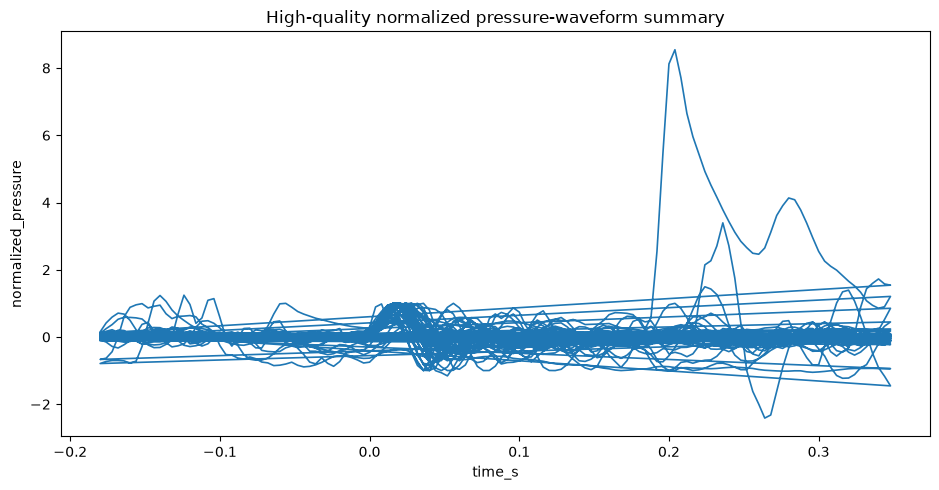

In [3]:
if ENSEMBLE_WAVEFORMS_FILE.is_file():
    ensemble = pd.read_csv(ENSEMBLE_WAVEFORMS_FILE)
    print("Loaded", ENSEMBLE_WAVEFORMS_FILE)
    display(ensemble.head())

    # Support either long-form or wide-form production products.
    numeric = ensemble.select_dtypes(include=[np.number])
    time_candidates = [c for c in ensemble.columns if "time" in c.lower()]

    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    if time_candidates and len(numeric.columns) >= 2:
        tcol = time_candidates[0]
        value_candidates = [
            c for c in numeric.columns
            if c != tcol and any(k in c.lower() for k in ("median", "mean", "pressure", "amplitude"))
        ]
        if value_candidates:
            ycol = value_candidates[0]
            ax.plot(ensemble[tcol], ensemble[ycol], lw=1.2)
            ax.set_xlabel(tcol)
            ax.set_ylabel(ycol)
            ax.set_title("High-quality normalized pressure-waveform summary")
        else:
            numeric.plot(ax=ax, legend=False, alpha=0.4)
            ax.set_title("High-quality normalized waveform product")
    else:
        numeric.plot(ax=ax, legend=False, alpha=0.4)
        ax.set_title("High-quality normalized waveform product")
    fig.tight_layout()
    fig.savefig(OUT / "high_quality_normalized_waveform_validation.pdf", bbox_inches="tight")
    plt.show()
else:
    print(
        "Ensemble product not present yet. Run production Notebook 070 to reproduce "
        "the high-quality normalized waveform ensemble."
    )

## Interpretation guardrails

Appropriate manuscript use after inspecting these plots:

- describe the strongest pressure pulses as **Friedlander-like** if the rapid compression and longer, smaller rarefaction are visually reproduced;
- state that the waveform morphology is consistent with blast-wave propagation;
- do **not** claim that morphology alone proves a supersonic source or determines a Mach number;
- do **not** use source times derived from the same BCHH arrivals to establish anomalous travel time.

The nonlinear-propagation timing argument belongs in production Notebook 080 and must use the independent same-camera UCS-3 source-event intervals versus the directly measured BCHH receiver intervals.

In [4]:
morphology.to_csv(OUT / "named_event_receiver_aligned_morphology_metrics.csv", index=False)
ARRIVALS[["event", "trace_id", "channel", "pick_time_utc"]].to_csv(
    OUT / "arrival_picks_used.csv", index=False
)
print("Wrote waveform morphology validation products to", OUT)

Wrote waveform morphology validation products to /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/055_validate_waveform_morphology
